# Baku Sentinel — Flood Risk Forecasting
## End-to-End Pipeline: Ingest → ETL → EDA → Train → Evaluate → Forecast

**Architecture:** Bronze → Silver → Gold medallion (DuckDB) · 6-hourly granularity  
**Model:** XGBoost + isotonic calibration · chronological split · SHAP explainability  
**Forecast:** 15-day live Open-Meteo data · per-zone risk scores & alerts

## Setup

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import duckdb
import shap
from scipy import stats
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

# Local project modules
sys.path.append(os.path.abspath('../'))
from src import config, ingestion, pipeline, model as mdl

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

C:\Users\TEXNO\PycharmProjects\Ironhack_Weather_Prediction\Weather-Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Historical Data Ingestion (Bronze Layer)

This step fetches hourly weather and daily river discharge data for the Baku zones via the Open-Meteo APIs. Data is stored in the Bronze layer of DuckDB.

In [2]:
ingestion.run_historical_ingest(
    start=config.HISTORICAL_START,
    end=config.HISTORICAL_END,
)

# Verify bronze tables
with duckdb.connect(str(config.DB_PATH)) as conn:
    tables_df = conn.execute("SHOW TABLES").df()

    # Simple check for bronze layer tables
    bronze_tables = conn.execute("""
        SELECT schema, name, column_names
        FROM (SHOW ALL TABLES)
        WHERE schema = 'bronze'
    """).df()

if not bronze_tables.empty:
    print(f"Bronze tables found: {len(bronze_tables)}")
    print(bronze_tables)
else:
    print("No bronze tables found.")

Bronze tables found: 6
   schema                         name  \
0  bronze        flood_raw_high_relief   
1  bronze         flood_raw_low_relief   
2  bronze    flood_raw_moderate_relief   
3  bronze      weather_raw_high_relief   
4  bronze       weather_raw_low_relief   
5  bronze  weather_raw_moderate_relief   

                                        column_names  
0                      [time, river_discharge, zone]  
1                      [time, river_discharge, zone]  
2                      [time, river_discharge, zone]  
3  [time, temperature_2m, relative_humidity_2m, p...  
4  [time, temperature_2m, relative_humidity_2m, p...  
5  [time, temperature_2m, relative_humidity_2m, p...  


## 2 · ETL Pipeline — Silver & Gold Layers

This pipeline transforms raw hourly data into a structured 6-hourly format (Silver) and then calculates all hydrological features (Gold) for the model.

In [3]:
pipeline.run_pipeline()

import duckdb as _ddb

conn = _ddb.connect(str(config.DB_PATH), read_only=True)
gold_exists = conn.execute("""
    SELECT count(*) FROM information_schema.tables
    WHERE table_schema = 'gold' AND table_name = 'flood_features'
""").fetchone()[0]
conn.close()

if not gold_exists:
    print("Gold table does not exist yet.")
    raise SystemExit("Stop here — run ETL first.")

conn = _ddb.connect(str(config.DB_PATH), read_only=True)
df_gold = conn.execute("SELECT * FROM gold.flood_features").df()
conn.close()

df_gold['time_6h'] = pd.to_datetime(df_gold['time_6h'])
print(f"Gold table  : {df_gold.shape[0]:,} rows × {df_gold.shape[1]} columns")
print(f"Date range  : {df_gold['time_6h'].min().date()} → {df_gold['time_6h'].max().date()}")
print(f"Zones       : {df_gold['zone'].unique().tolist()}")
print(f"Flood rate  : {df_gold['is_flood'].mean()*100:.3f}%")
print(f"Columns     : {df_gold.columns.tolist()}")
df_gold.head(3)


Gold table  : 27,624 rows × 39 columns
Date range  : 2020-01-01 → 2026-04-20
Zones       : ['Low Relief', 'High Relief', 'Moderate Relief']
Flood rate  : 1.061%
Columns     : ['zone', 'time_6h', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_temperature_0_to_7cm', 'et0_fao_evapotranspiration', 'precip_lag_6h', 'precip_lag_12h', 'precip_lag_24h', 'precip_lag_48h', 'temp_lag_24h', 'precip_roll_sum_24h', 'precip_roll_sum_48h', 'precip_roll_sum_72h', 'precip_roll_max_24h', 'humidity_roll_max_24h', 'et0_roll_sum_24h', 'api_7d', 'soil_saturation_index', 'soil_moisture_change_6h', 'soil_moisture_deficit', 'frozen_ground_flag', 'temp_trend_24h', 'et_deficit_6h', 'et_deficit_24h', 'humidity_precip_product', 'highland_precip_24h', 'zone_cascade_risk', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_winter', 'dq_score', 'is_flood']


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,temp_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,humidity_roll_max_24h,et0_roll_sum_24h,api_7d,soil_saturation_index,soil_moisture_change_6h,soil_moisture_deficit,frozen_ground_flag,temp_trend_24h,et_deficit_6h,et_deficit_24h,humidity_precip_product,highland_precip_24h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,dq_score,is_flood
0,Low Relief,2024-11-29 00:00:00,7.2667,89.5000,0.2000,14.7833,0.3600,0.3243,7.9667,0.0000,2.3000,0.2000,0.0000,7.3000,8.4667,2.9000,3.0000,14.4000,2.3000,89.5000,0.6600,2.2995,0.3422,0.0083,0.1078,0,-1.2000,0.2000,2.2400,17.9000,1.6000,1.6000,0.0000,1.0000,-0.5087,0.8610,1,1.0000,0
1,Low Relief,2024-11-29 06:00:00,7.3000,85.0000,0.2000,14.3333,0.3410,0.3230,7.7500,0.1800,0.2000,2.3000,0.2000,0.1000,7.8833,2.9000,3.1000,10.5000,2.3000,89.5000,0.6900,2.1362,0.3320,-0.0190,0.1180,0,-0.5833,0.0200,2.2100,17.0000,2.0000,2.0000,1.0000,0.0000,-0.5087,0.8610,1,1.0000,0
2,Low Relief,2024-11-29 12:00:00,8.5333,74.6667,0.0000,20.8167,0.3382,0.3223,8.9167,0.4700,0.2000,0.2000,0.2000,0.0000,9.3667,2.7000,3.1000,10.5000,2.3000,89.5000,0.6600,0.4189,0.3303,-0.0028,0.1197,0,-0.8333,-0.4700,2.0400,0.0000,1.6000,1.6000,0.0000,-1.0000,-0.5087,0.8610,1,1.0000,0


## 3 · Exploratory Data Analysis

### 3.1 · Missing values & data quality

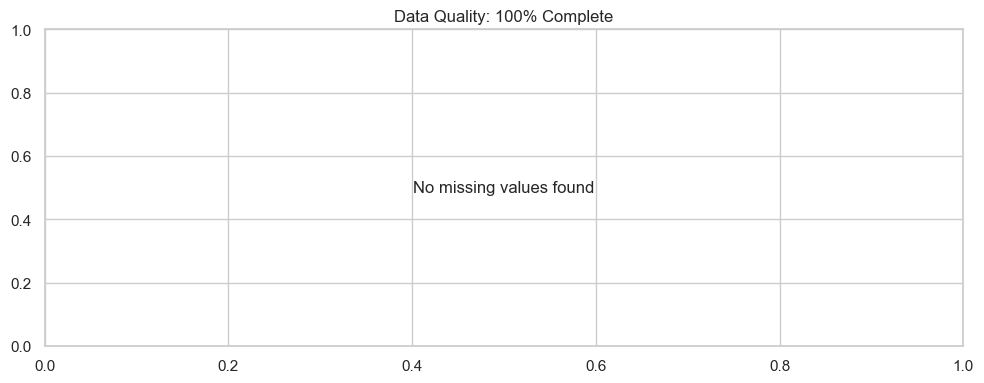

Total NaN count: 0


In [4]:
# Check for missing values
missing_data = df_gold.isnull().mean().sort_values(ascending=False)
missing_only = missing_data[missing_data > 0]

# Visualize missingness
plt.figure(figsize=(10, 4))
if len(missing_only) > 0:
    missing_only.plot(kind='barh', color='salmon')
    plt.title('Missing Value Rate per Feature')
    plt.xlabel('Fraction of Missing Data')
else:
    plt.text(0.5, 0.5, 'No missing values found', ha='center', va='center')
    plt.title('Data Quality: 100% Complete')

plt.tight_layout()
plt.show()

print(f"Total NaN count: {df_gold.isnull().sum().sum()}")

### 3.2 · Flood event distribution by zone & season

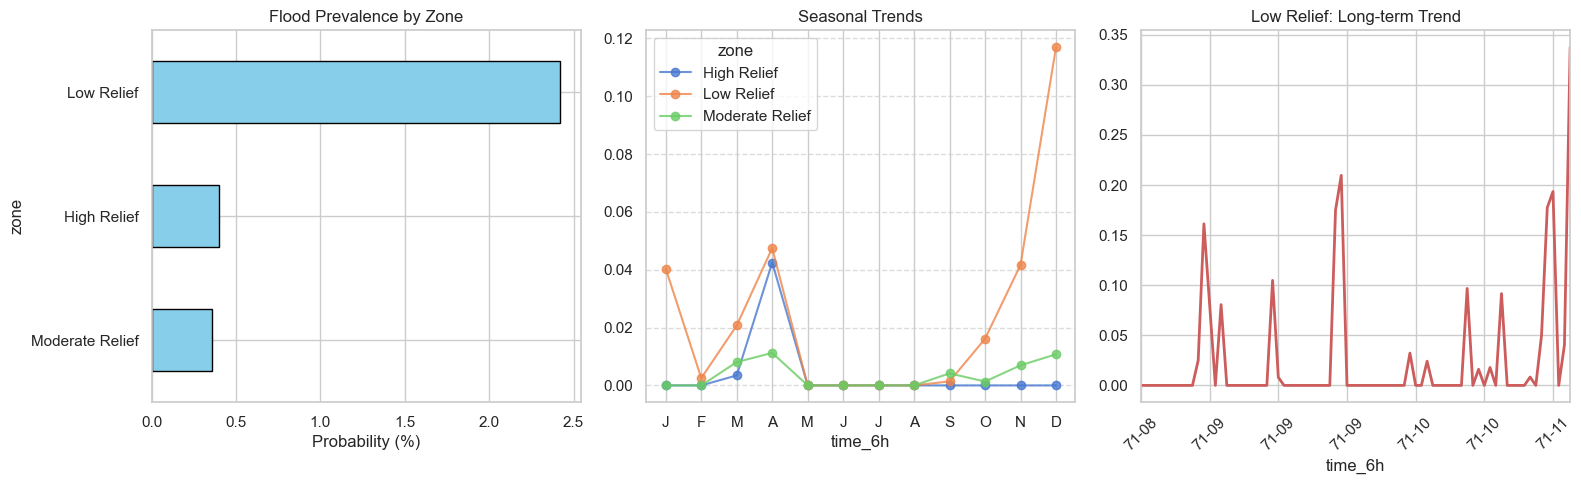

In [5]:
# Create a 3-panel EDA dashboard
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Spatial Analysis: Flood rate by zone
(df_gold.groupby('zone')['is_flood'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Flood Prevalence by Zone')
axes[0].set_xlabel('Probability (%)')

# 2. Seasonal Analysis: Seasonality of flood events
# Using dt.month directly for grouping
monthly_stats = df_gold.pivot_table(index=df_gold['time_6h'].dt.month,
                                   columns='zone',
                                   values='is_flood',
                                   aggfunc='mean')
monthly_stats.plot(ax=axes[1], marker='o', alpha=0.8)
axes[1].set_title('Seasonal Trends')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Temporal Analysis: Low Relief timeline
low_relief = df_gold[df_gold['zone'] == 'Low Relief'].set_index('time_6h')
low_relief['is_flood'].resample('ME').mean().plot(
    ax=axes[2], color='indianred', linewidth=2
)
axes[2].set_title('Low Relief: Long-term Trend')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 3.3 · Correlation analysis — Spearman ρ with is_flood

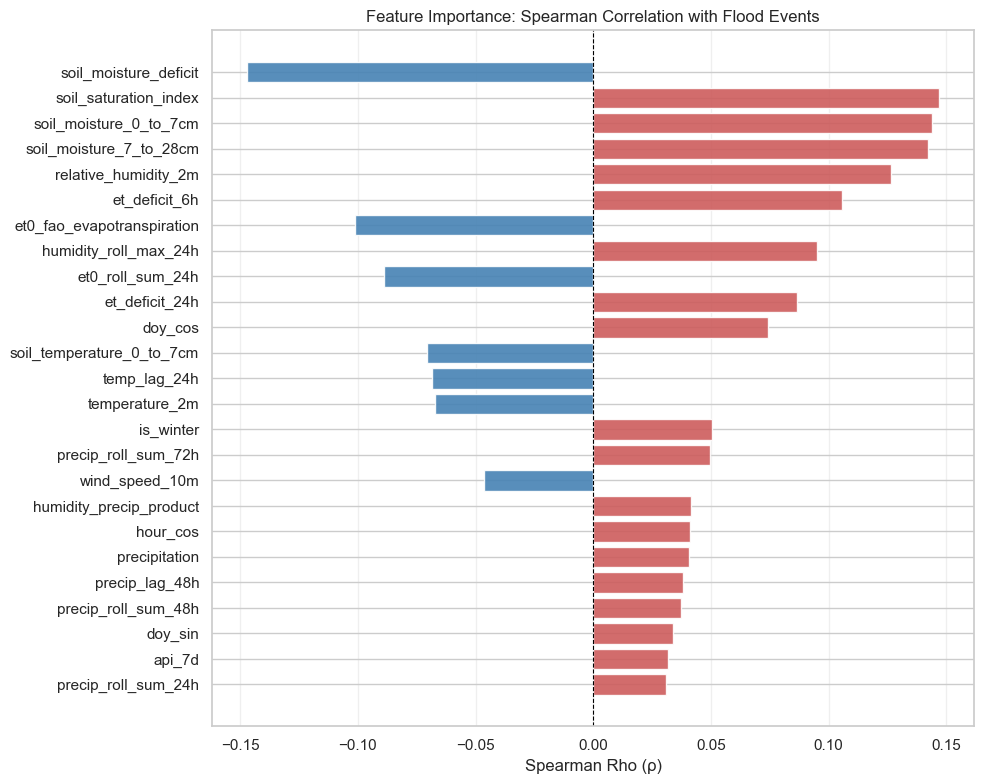

Strongest Positive Drivers:
                    feature    rho
20    soil_saturation_index 0.1471
4    soil_moisture_0_to_7cm 0.1439
5   soil_moisture_7_to_28cm 0.1424
1      relative_humidity_2m 0.1267
25            et_deficit_6h 0.1059
17    humidity_roll_max_24h 0.0952
26           et_deficit_24h 0.0866
33                  doy_cos 0.0741
34                is_winter 0.0504
15      precip_roll_sum_72h 0.0498


In [6]:
# Identify numerical features and target
num_cols = df_gold.select_dtypes(include='number').columns.drop('is_flood').tolist()
target = 'is_flood'

# Calculate Spearman correlation for each feature
correlations = []
for col in num_cols:
    # Drop NaNs to ensure clean calculation
    valid_data = df_gold[[col, target]].dropna()

    if len(valid_data) > 50:
        rho, pval = stats.spearmanr(valid_data[col], valid_data[target])
        correlations.append({'feature': col, 'rho': rho, 'pval': pval})

# Create correlation dataframe and take top 25
corr_df = pd.DataFrame(correlations)
corr_df['abs_rho'] = corr_df['rho'].abs()
top_features = corr_df.sort_values('abs_rho', ascending=False).head(25)

# Visualize Top 25 correlations
plt.figure(figsize=(10, 8))
colors = ['indianred' if r > 0 else 'steelblue' for r in top_features['rho']]

plt.barh(top_features['feature'], top_features['rho'], color=colors, alpha=0.9)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.title('Feature Importance: Spearman Correlation with Flood Events')
plt.xlabel('Spearman Rho (ρ)')
plt.gca().invert_yaxis() # Highest correlation at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Quick insights
print("Strongest Positive Drivers:")
print(top_features[top_features['rho'] > 0][['feature', 'rho']].head(10))

### 3.4 · Multicollinearity Analysis: Identifying Redundant Features

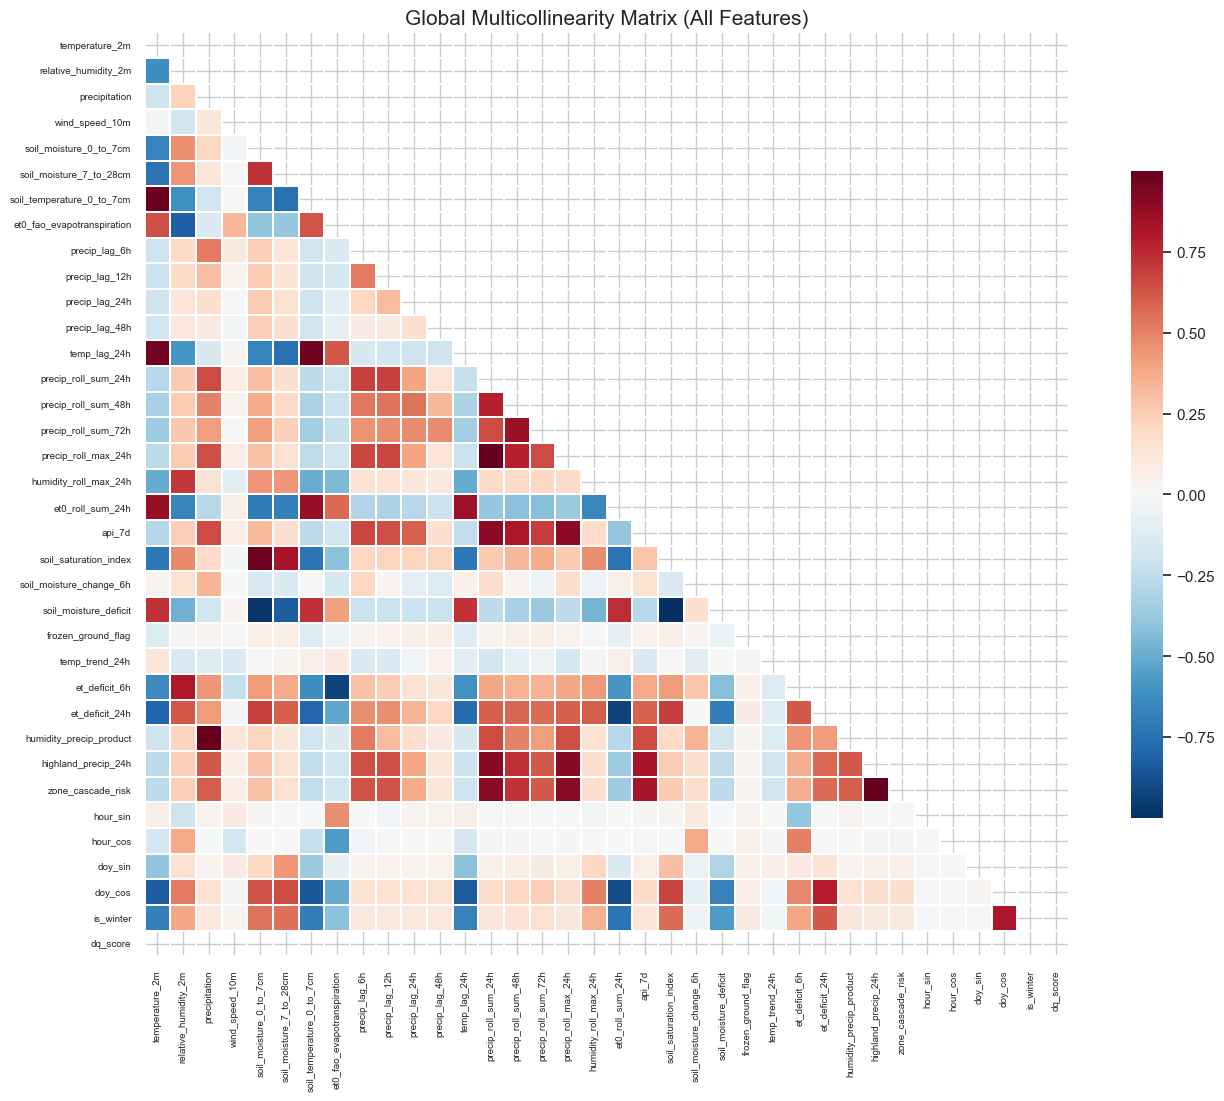

Top Redundant Feature Pairs (>0.90):
----------------------------------------
precipitation              humidity_precip_product     0.9999
precip_roll_sum_24h        precip_roll_max_24h         0.9991
highland_precip_24h        zone_cascade_risk           0.9978
temperature_2m             soil_temperature_0_to_7cm   0.9852
soil_moisture_0_to_7cm     soil_saturation_index       0.9765
soil_temperature_0_to_7cm  temp_lag_24h                0.9691
temperature_2m             temp_lag_24h                0.9661
precip_roll_sum_24h        highland_precip_24h         0.9128
precip_roll_max_24h        highland_precip_24h         0.9115
precip_roll_sum_24h        zone_cascade_risk           0.9061
precip_roll_max_24h        zone_cascade_risk           0.9048
dtype: float64


In [7]:
# 1. Calculate correlation for all numerical features
all_num_features = df_gold.select_dtypes(include='number').columns.drop('is_flood')
full_corr_matrix = df_gold[all_num_features].corr(method='spearman')

# 2. Setup the visualization with forced labels
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(full_corr_matrix, dtype=bool))

sns.heatmap(full_corr_matrix,
            mask=mask,
            annot=False,
            cmap='RdBu_r',
            center=0,
            linewidths=0.05,
            square=True,
            cbar_kws={"shrink": .7},
            xticklabels=True,
            yticklabels=True)

plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.title('Global Multicollinearity Matrix (All Features)', fontsize=15)
plt.show()

# 3. Extract and display redundant pairs (>0.90)
upper_tri = full_corr_matrix.where(np.triu(np.ones(full_corr_matrix.shape), k=1).astype(bool))
redundant_pairs = upper_tri.stack().sort_values(ascending=False)

print("Top Redundant Feature Pairs (>0.90):")
print("-" * 40)
print(redundant_pairs[redundant_pairs > 0.90])

In [8]:
# Definitive list of redundant or non-predictive features to exclude
exclude_list = [
    'humidity_precip_product',   # Proxy for raw precipitation
    'precip_roll_max_24h',       # Redundant with precip_roll_sum_24h
    'zone_cascade_risk',         # Redundant with highland_precip_24h
    'soil_temperature_0_to_7cm', # Redundant with air temperature_2m
    'soil_saturation_index',     # Redundant with soil_moisture_0_to_7cm
    'river_discharge',           # Using lags instead to ensure predictive power
    'discharge_roll_max_24h',    # Redundant with discharge_lag_6h
    'temp_lag_24h',              # Redundant with temperature_2m
    'discharge_lag_24h',         # Redundant with discharge_lag_6h
    'precip_roll_sum_24h'        # Redundant with highland_precip_24h
]

# Create the final feature list from all available numerical columns
final_features = [f for f in all_num_features if f not in exclude_list]

print(f"Features filtered: {len(all_num_features)} → {len(final_features)}")
print("-" * 30)
print("Final Model Input Features:")
print(final_features)

# Create the model-ready dataframe
# We keep 'is_flood' and 'time_6h' for splitting and evaluation logic
df_model = df_gold[final_features + ['is_flood', 'time_6h']].copy()

print("-" * 30)
print(f"Cleanup complete: {len(exclude_list)} redundant features removed.")
print(f"Total features retained: {len(final_features)}")

Features filtered: 36 → 29
------------------------------
Final Model Input Features:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'et0_fao_evapotranspiration', 'precip_lag_6h', 'precip_lag_12h', 'precip_lag_24h', 'precip_lag_48h', 'precip_roll_sum_48h', 'precip_roll_sum_72h', 'humidity_roll_max_24h', 'et0_roll_sum_24h', 'api_7d', 'soil_moisture_change_6h', 'soil_moisture_deficit', 'frozen_ground_flag', 'temp_trend_24h', 'et_deficit_6h', 'et_deficit_24h', 'highland_precip_24h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_winter', 'dq_score']
------------------------------
Cleanup complete: 10 redundant features removed.
Total features retained: 29


### 3.5 · Mann-Whitney U test — flood vs. non-flood distributions

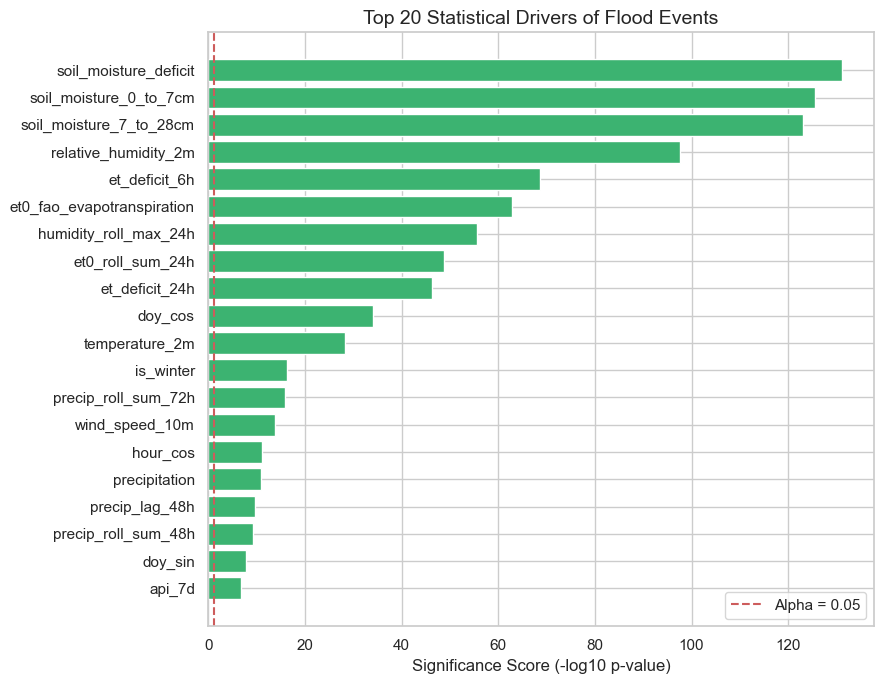

Statistical Summary: 26 / 29 features are significant (p < 0.05)


,Feature,Flood Median,Normal Median,Difference,p_value
17,soil_moisture_deficit,0.1318,0.2816,-0.1498,0.0000
4,soil_moisture_0_to_7cm,0.3180,0.1610,0.1570,0.0000
5,soil_moisture_7_to_28cm,0.3168,0.1863,0.1305,0.0000
1,relative_humidity_2m,88.6667,73.5000,15.1667,0.0000
20,et_deficit_6h,0.0000,-0.4100,0.4100,0.0000
6,et0_fao_evapotranspiration,0.0700,0.4600,-0.3900,0.0000
13,humidity_roll_max_24h,90.5000,83.8333,6.6667,0.0000
14,et0_roll_sum_24h,1.2300,2.8100,-1.5800,0.0000
21,et_deficit_24h,-0.8800,-2.4800,1.6000,0.0000
26,doy_cos,0.7498,0.0387,0.7111,0.0000


In [9]:
# Separate classes to compare distributions
flood_samples = df_gold[df_gold['is_flood'] == 1]
normal_samples = df_gold[df_gold['is_flood'] == 0]

comparison_results = []

# Analyze every feature in the final set
for col in final_features:
    f_data = flood_samples[col].dropna()
    nf_data = normal_samples[col].dropna()

    # Statistically sound check: minimum 15 samples per class
    if len(f_data) > 15 and len(nf_data) > 15:
        stat, pval = stats.mannwhitneyu(f_data, nf_data, alternative='two-sided')

        comparison_results.append({
            'Feature': col,
            'Flood Median': f_data.median(),
            'Normal Median': nf_data.median(),
            'Difference': f_data.median() - nf_data.median(),
            'p_value': pval
        })

# Store all results, sorted by the most significant (lowest p-value)
stats_df = pd.DataFrame(comparison_results).sort_values('p_value')

# Visualization: Show Top 20 to maintain readability
plt.figure(figsize=(9, 7))
top_stats = stats_df.head(20)

plt.barh(top_stats['Feature'],
         -np.log10(top_stats['p_value'] + 1e-300),
         color='mediumseagreen')

plt.axvline(-np.log10(0.05), color='indianred', linestyle='--', label='Alpha = 0.05')

plt.title('Top 20 Statistical Drivers of Flood Events', fontsize=14)
plt.xlabel('Significance Score (-log10 p-value)')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

# Print summary for the entire feature set
significant_count = sum(stats_df['p_value'] < 0.05)
print(f"Statistical Summary: {significant_count} / {len(stats_df)} features are significant (p < 0.05)")

# Show the Top 10 strongest features numerically
display(stats_df[['Feature', 'Flood Median', 'Normal Median', 'Difference', 'p_value']].head(10))

In [10]:
# Identify features that are not statistically significant (p >= 0.05)
insignificant_features = stats_df[stats_df['p_value'] >= 0.05]['Feature'].tolist()

# Create the final list by keeping only significant, non-redundant features
model_ready_features = [f for f in final_features if f not in insignificant_features]

print(f"Initial candidates: {len(final_features)}")
print(f"Dropped for lack of significance: {len(insignificant_features)} ({insignificant_features})")
print(f"Final features for df_model: {len(model_ready_features)}")

Initial candidates: 29
Dropped for lack of significance: 3 (['frozen_ground_flag', 'temp_trend_24h', 'dq_score'])
Final features for df_model: 26


In [11]:
# Rebuild the final dataframe
# We keep the features, the target, and the time for splitting
df_model = df_gold[model_ready_features + ['is_flood', 'time_6h']].copy()

print("-" * 30)
print("Final Features Retained:")
print(model_ready_features)

------------------------------
Final Features Retained:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'et0_fao_evapotranspiration', 'precip_lag_6h', 'precip_lag_12h', 'precip_lag_24h', 'precip_lag_48h', 'precip_roll_sum_48h', 'precip_roll_sum_72h', 'humidity_roll_max_24h', 'et0_roll_sum_24h', 'api_7d', 'soil_moisture_change_6h', 'soil_moisture_deficit', 'et_deficit_6h', 'et_deficit_24h', 'highland_precip_24h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_winter']


### 3.6 · Feature distributions — flood vs. non-flood

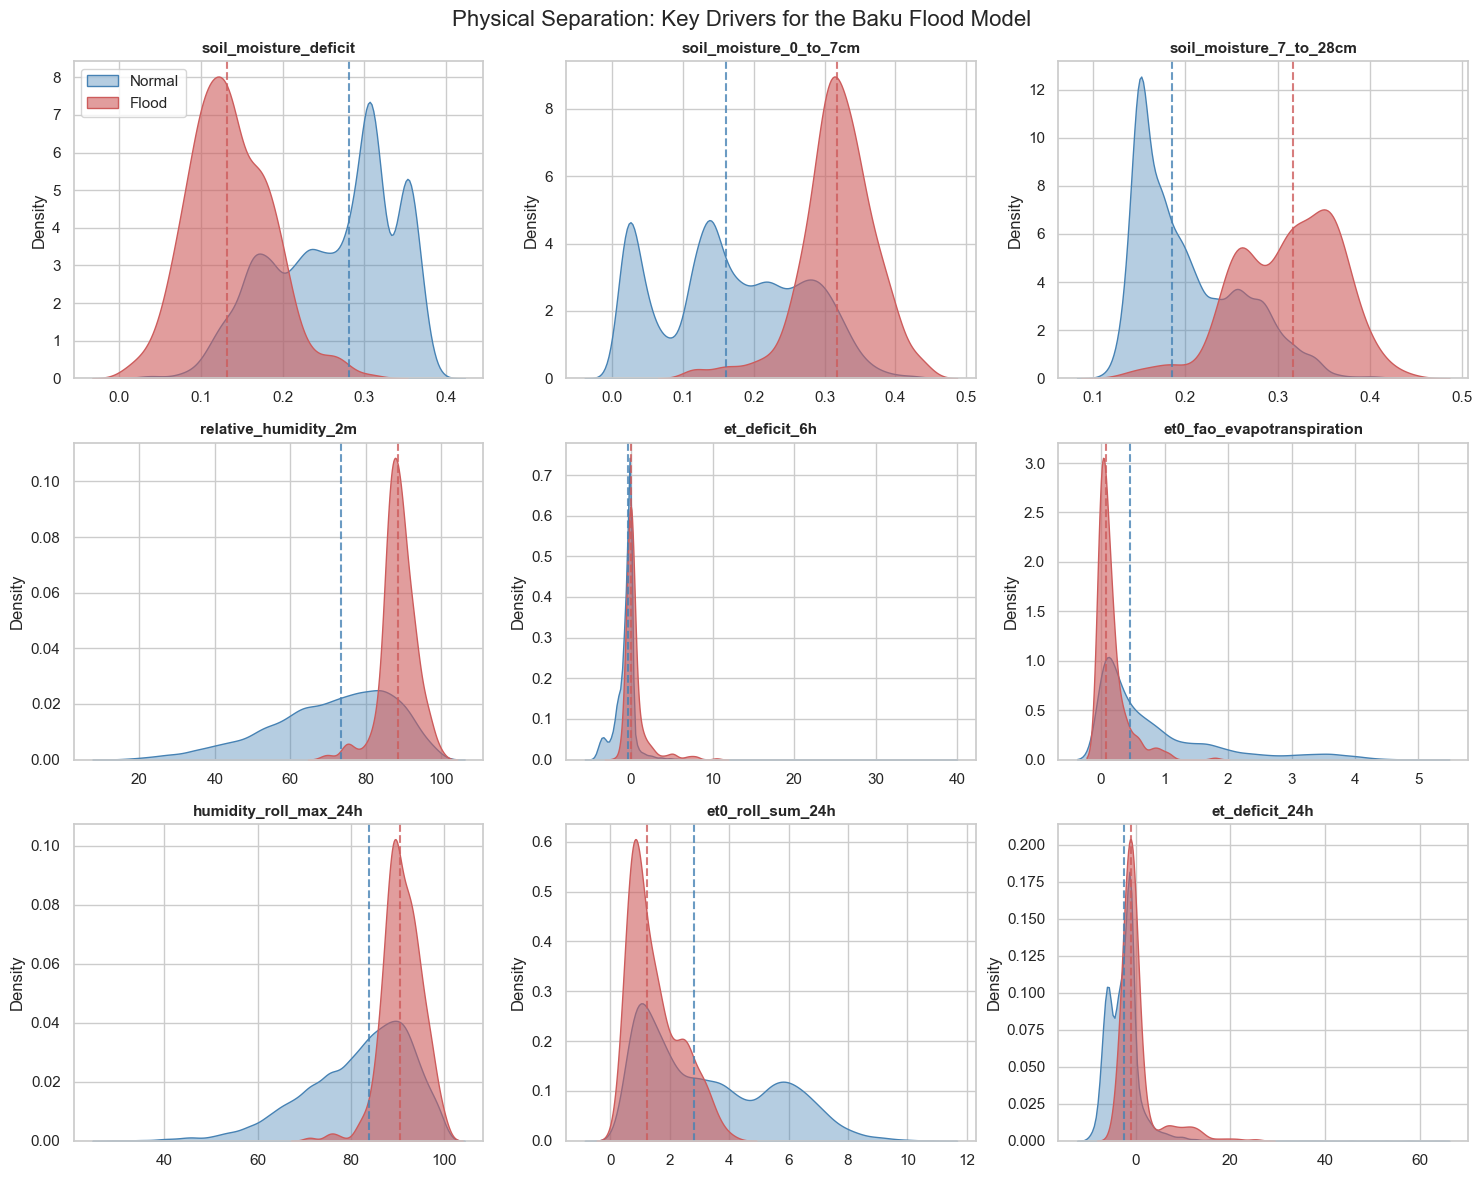

In [12]:
# 1. Identify the top 9 most significant features from our cleaned model list
# This ensures we only plot features we are actually keeping for the model
model_ready_stats = stats_df[stats_df['Feature'].isin(model_ready_features)]
plot_features = model_ready_stats['Feature'].head(9).tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    ax = axes[i]

    f_vals = flood_samples[feat].dropna()
    n_vals = normal_samples[feat].dropna()

    # Plotting distributions
    sns.kdeplot(n_vals, ax=ax, fill=True, color='steelblue', label='Normal', alpha=0.4)
    sns.kdeplot(f_vals, ax=ax, fill=True, color='indianred', label='Flood', alpha=0.6)

    # Adding vertical lines for medians to show the 'gap'
    ax.axvline(n_vals.median(), color='steelblue', linestyle='--', alpha=0.8)
    ax.axvline(f_vals.median(), color='indianred', linestyle='--', alpha=0.8)

    ax.set_title(f"{feat}", fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel('')

    if i == 0:
        ax.legend(frameon=True)

plt.suptitle('Physical Separation: Key Drivers for the Baku Flood Model', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

### 3.7 · Correlation heatmap — top engineered features

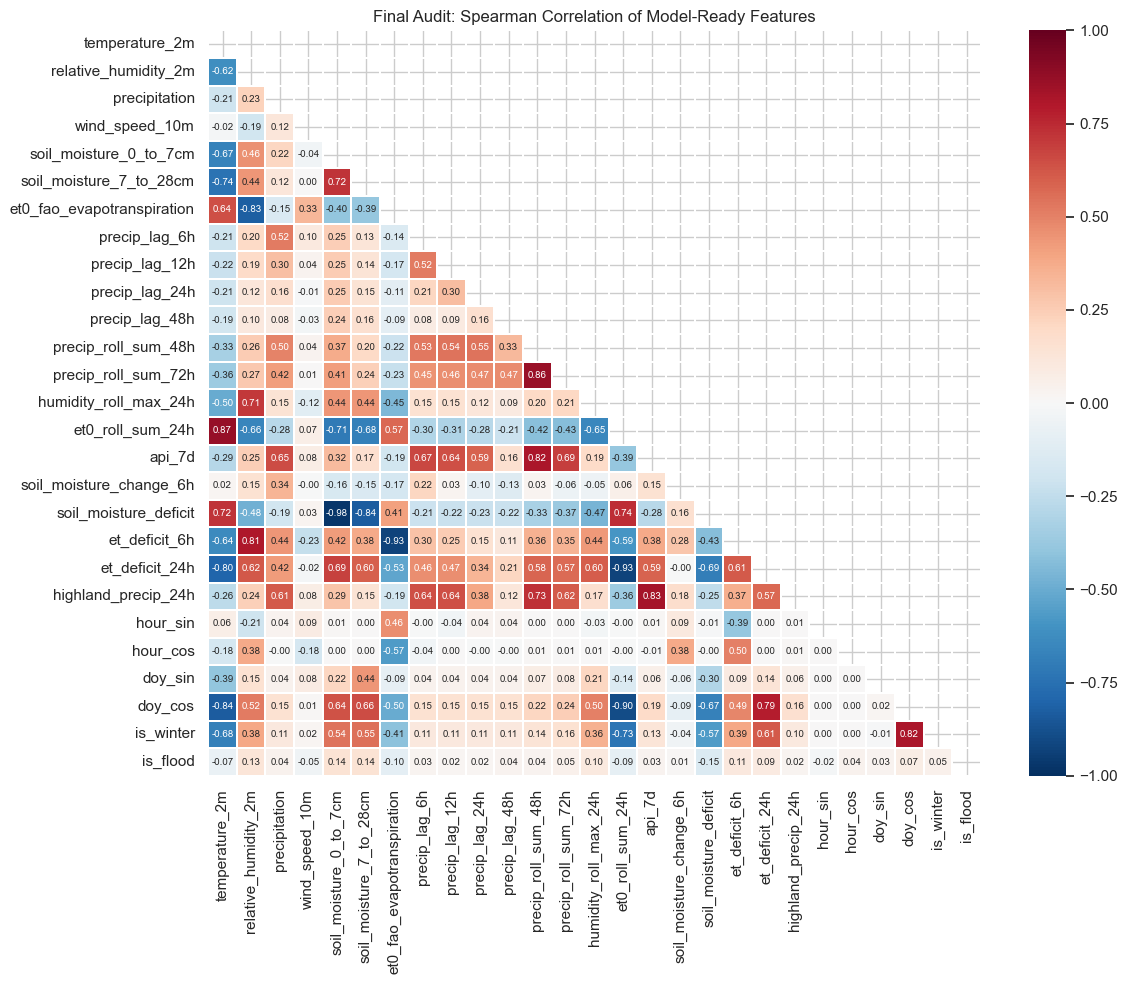

In [13]:
# We include 'is_flood' just to see how the final features correlate with the target
final_audit_features = model_ready_features + ['is_flood']

# Create the visualization
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_gold[final_audit_features].corr(method='spearman')

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 7},
    linewidths=0.3
)

ax.set_title('Final Audit: Spearman Correlation of Model-Ready Features')
plt.tight_layout()
plt.show()

## 4 · Model Training

XGBoost classifier with:
- Chronological train/test split (last 20% of time = test)
- `scale_pos_weight` to handle class imbalance
- Isotonic calibration for reliable probabilities

In [14]:
bundle = mdl.train(df_gold, calibrate=True)

print("\n── Model Metrics ──────────────────────────────────────────")
for k, v in bundle['metrics'].items():
    if k not in ('report', 'cv_auc_pr_mean', 'cv_auc_pr_std'):
        print(f"  {k:25s}: {v}")
print(f"  {'cv_auc_pr':25s}: {bundle['metrics']['cv_auc_pr_mean']:.4f} ± {bundle['metrics']['cv_auc_pr_std']:.4f}")


── Model Metrics ──────────────────────────────────────────
  auc_roc                  : 0.9181
  auc_pr                   : 0.4752
  f1_score                 : 0.4881
  threshold                : 0.06
  n_train                  : 22098
  n_test                   : 5526
  pos_rate_train           : 0.006199656077473074
  pos_rate_test            : 0.02823018458197611
  cv_auc_pr                : 0.2536 ± 0.2373


In [15]:
# Print the full list of features used
print(f"Total features used: {len(bundle['features'])}")
print("-" * 30)
for feature in bundle['features']:
    print(f" - {feature}")

Total features used: 27
------------------------------
 - temperature_2m
 - relative_humidity_2m
 - precipitation
 - wind_speed_10m
 - soil_moisture_0_to_7cm
 - soil_moisture_7_to_28cm
 - et0_fao_evapotranspiration
 - precip_lag_6h
 - precip_lag_12h
 - precip_lag_24h
 - precip_lag_48h
 - precip_roll_sum_48h
 - precip_roll_sum_72h
 - humidity_roll_max_24h
 - et0_roll_sum_24h
 - api_7d
 - soil_moisture_deficit
 - et_deficit_6h
 - et_deficit_24h
 - highland_precip_24h
 - hour_sin
 - hour_cos
 - doy_sin
 - doy_cos
 - is_winter
 - zone_Low Relief
 - zone_Moderate Relief


## 5 · Model Evaluation

### 5.1 · ROC, Precision-Recall curves & Confusion Matrix

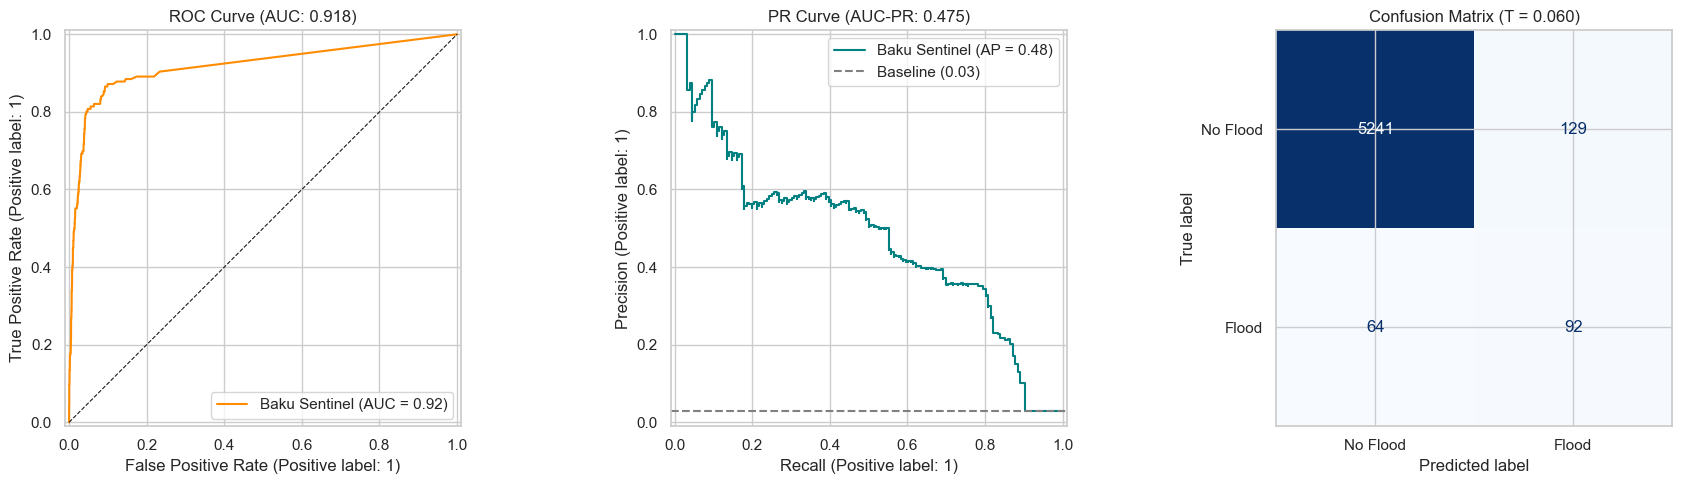


── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.99      0.98      0.98      5370
       Flood       0.42      0.59      0.49       156

    accuracy                           0.97      5526
   macro avg       0.70      0.78      0.73      5526
weighted avg       0.97      0.97      0.97      5526



In [16]:
test_df   = bundle['test_df']
y_test    = test_df['is_flood'].values
y_prob    = test_df['risk_score'].values
y_pred    = test_df['flood_pred'].values
threshold = bundle['threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='Baku Sentinel', color='darkorange')
axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_title(f"ROC Curve (AUC: {roc_auc_score(y_test, y_prob):.3f})")

# 2. Precision-Recall Curve (The most important one for floods)
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='Baku Sentinel', color='teal')
# Add a baseline for random guessing (fraction of positives)
baseline = y_test.sum() / len(y_test)
axes[1].axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_title(f"PR Curve (AUC-PR: {average_precision_score(y_test, y_prob):.3f})")
axes[1].legend()

# 3. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[2],
                                         colorbar=False, cmap='Blues',
                                         display_labels=['No Flood', 'Flood'])
axes[2].set_title(f"Confusion Matrix (T = {threshold:.3f})")

plt.tight_layout()
plt.show()

# 4. Detailed Metrics
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['No Flood','Flood'], zero_division=0))

### 5.2 · Calibration curve

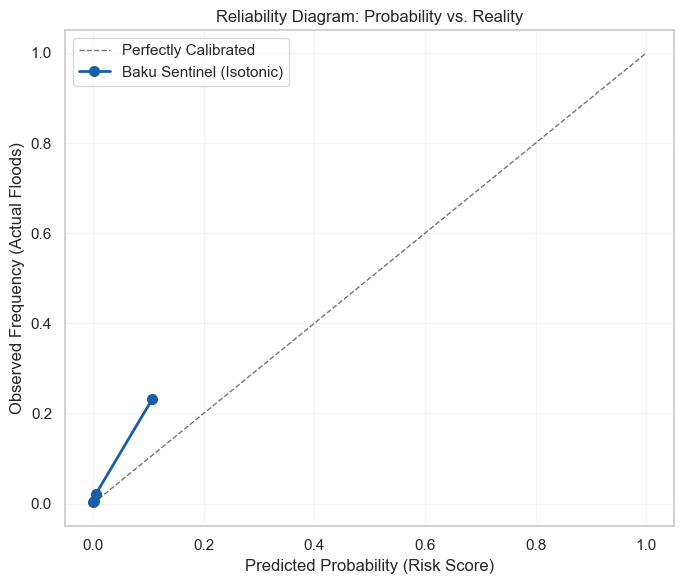

In [17]:
from sklearn.calibration import calibration_curve

# Using 'quantile' to ensure every point has a statistically significant number of samples
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6))

# Perfect calibration line
ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.6, label='Perfectly Calibrated')

# Our model's performance
ax.plot(mean_pred, fraction_pos, 'o-', color='#185FA5', lw=2,
        label='Baku Sentinel (Isotonic)', markersize=7)

# Visual polish
ax.set_xlabel('Predicted Probability (Risk Score)')
ax.set_ylabel('Observed Frequency (Actual Floods)')
ax.set_title('Reliability Diagram: Probability vs. Reality')
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

### 5.3 · Threshold sensitivity — F1, Precision, Recall vs. threshold

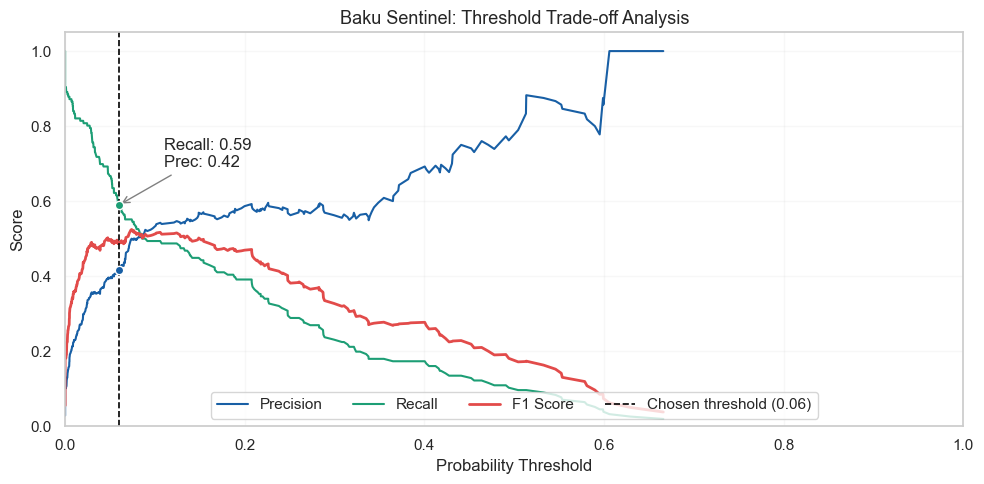

In [18]:
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)

# Find values at the chosen threshold (0.30)
idx = np.argmin(np.abs(thresholds_arr - threshold))
p_at_t = precision_arr[idx]
r_at_t = recall_arr[idx]

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the three curves
ax.plot(thresholds_arr, precision_arr[:-1], label='Precision', color='#185FA5', lw=1.5)
ax.plot(thresholds_arr, recall_arr[:-1],    label='Recall',    color='#1D9E75', lw=1.5)
ax.plot(thresholds_arr, f1_arr[:-1],        label='F1 Score',  color='#E24B4A', lw=2)

ax.axvline(threshold, color='black', linestyle='--', lw=1.2, label=f'Chosen threshold ({threshold:.2f})')
ax.scatter([threshold], [p_at_t], color='#185FA5', edgecolors='white', zorder=5)
ax.scatter([threshold], [r_at_t], color='#1D9E75', edgecolors='white', zorder=5)

# Visual Polish
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Score')
ax.set_title('Baku Sentinel: Threshold Trade-off Analysis', fontsize=13)
ax.legend(frameon=True, loc='lower center', ncol=4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.15)

# Annotation to explain the choice
ax.annotate(f'Recall: {r_at_t:.2f}\nPrec: {p_at_t:.2f}',
            xy=(threshold, r_at_t), xytext=(threshold+0.05, r_at_t+0.1),
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

### 5.4 · Risk score distribution by true label

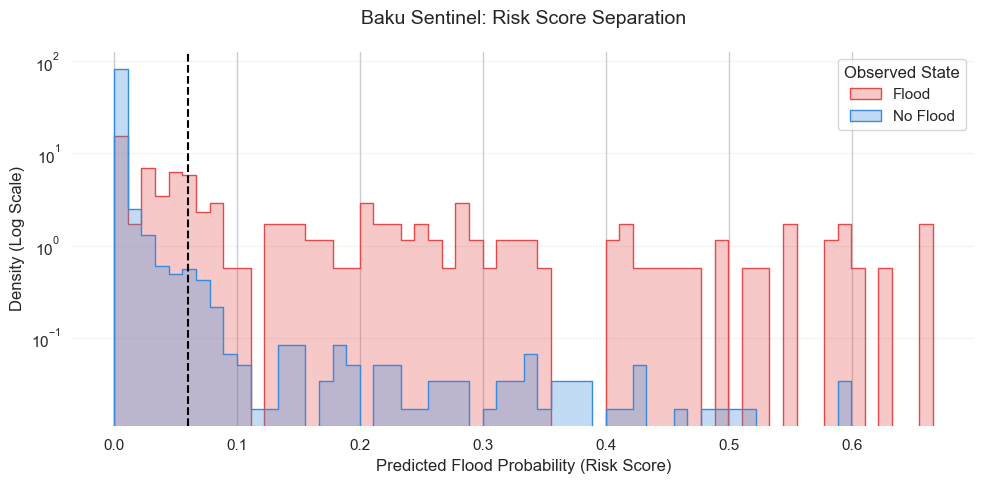

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=test_df, x='risk_score', hue='is_flood',
             element='step', bins=60, stat='density', common_norm=False,
             palette={0: '#378ADD', 1: '#E24B4A'}, alpha=0.3, ax=ax)

# Threshold line
ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
           label=f'Alert Threshold ({threshold:.2f})')

# Log scale is essential for rare event visibility
ax.set_yscale('log')

# Labels and Title
ax.set_xlabel('Predicted Flood Probability (Risk Score)')
ax.set_ylabel('Density (Log Scale)')
ax.set_title('Baku Sentinel: Risk Score Separation', fontsize=14, pad=20)

# Cleaning up the frame
sns.despine(left=True, bottom=True)
ax.grid(axis='y', alpha=0.2)

# Legend refinement
ax.legend(title='Observed State', labels=['Flood', 'No Flood'])

plt.tight_layout()
plt.show()

### 5.5 · Temporal error analysis — risk score over test period

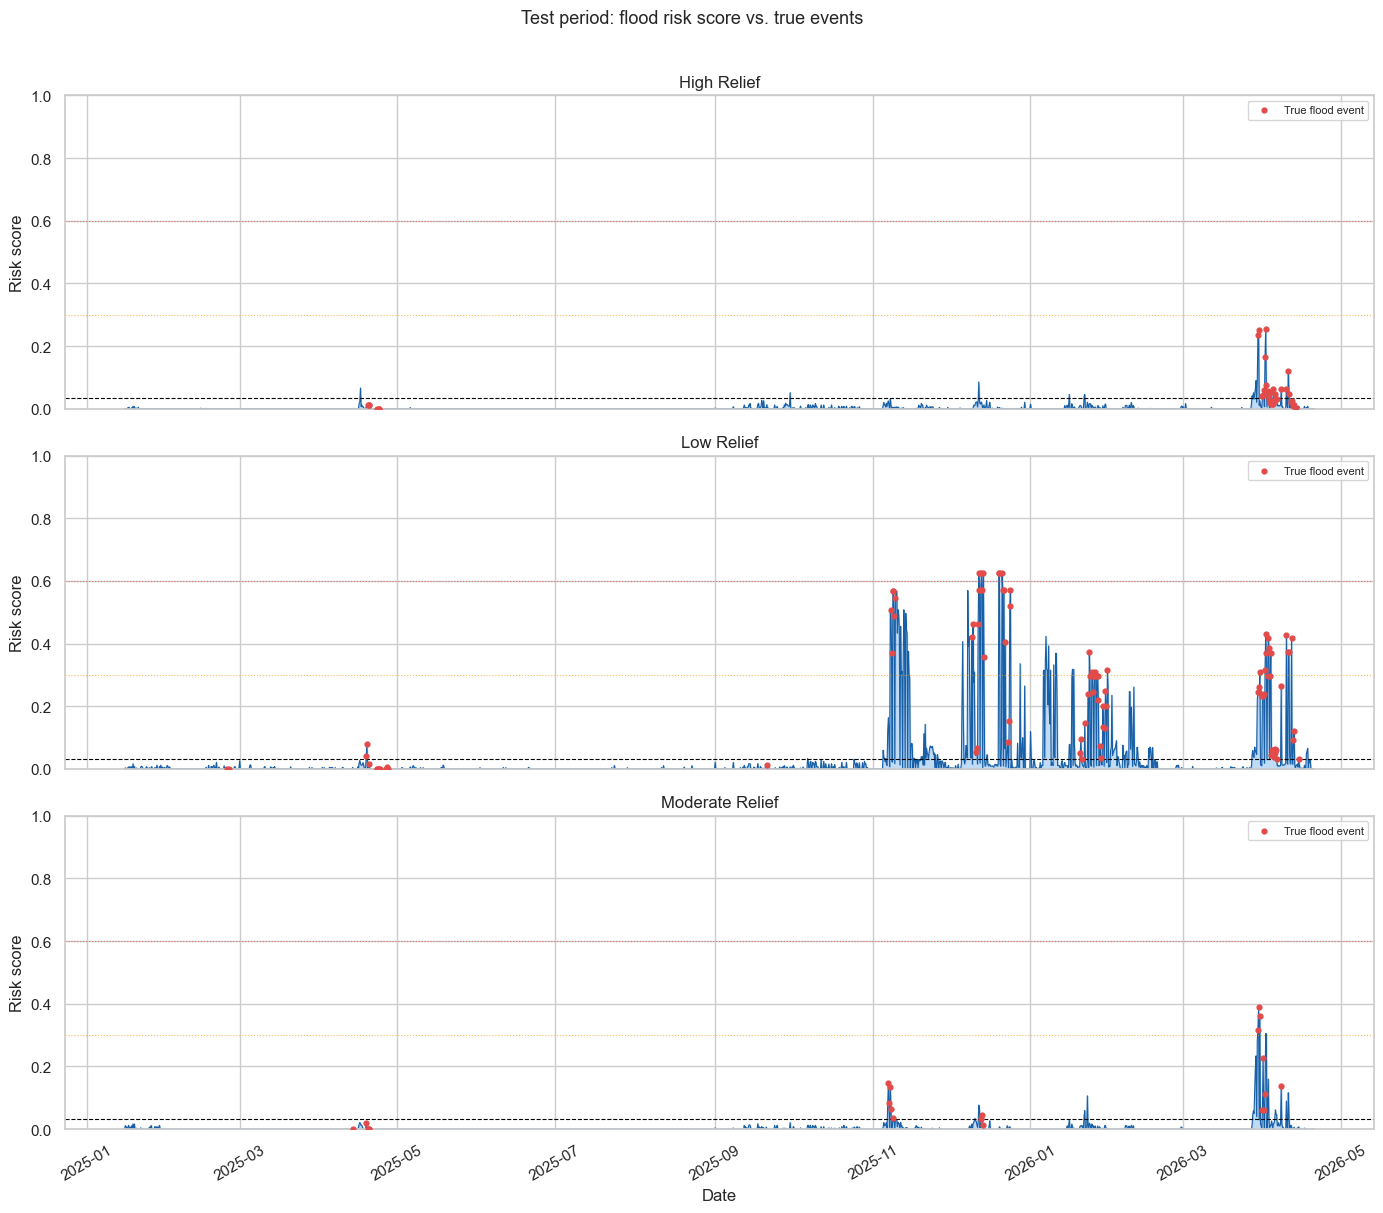

In [20]:
fig, axes = plt.subplots(len(config.BAKU_ZONES), 1,
                          figsize=(14, 4 * len(config.BAKU_ZONES)), sharex=True)

for ax, zone_cfg in zip(axes, config.BAKU_ZONES):
    zone = zone_cfg['zone']
    zdf  = test_df[test_df['zone'] == zone].sort_values('time_6h')
    ax.fill_between(zdf['time_6h'], zdf['risk_score'], alpha=0.3, color='#378ADD')
    ax.plot(zdf['time_6h'], zdf['risk_score'], lw=0.8, color='#185FA5')
    floods = zdf[zdf['is_flood'] == 1]
    ax.scatter(floods['time_6h'], floods['risk_score'],
               color='#E24B4A', s=12, zorder=5, label='True flood event')
    ax.axhline(threshold, color='black', linestyle='--', lw=0.8)
    ax.axhline(config.RISK_HIGH,   color='#E24B4A', linestyle=':', lw=0.8, alpha=0.7)
    ax.axhline(config.RISK_MEDIUM, color='#EF9F27', linestyle=':', lw=0.8, alpha=0.7)
    ax.set_ylabel('Risk score')
    ax.set_title(f'{zone}')
    ax.set_ylim(0, 1)
    if floods.shape[0] > 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Test period: flood risk score vs. true events', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6 · SHAP Feature Importance & Explainability

In [21]:
# Rebuild SHAP values for the test set
checkpoint = mdl.load_model()
feature_cols = checkpoint['features']

drop_cols = ['time_6h', 'river_discharge', 'is_flood',
             'risk_score', 'flood_pred', 'risk_level']
X_test_raw = pd.get_dummies(
    test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]),
    columns=['zone'], drop_first=True
)
for c in feature_cols:
    if c not in X_test_raw.columns:
        X_test_raw[c] = 0
X_test_enc = X_test_raw[feature_cols].fillna(0)

# Get the base XGBoost estimator for SHAP
base_model = checkpoint['model']
if hasattr(base_model, 'estimator'):          # CalibratedClassifierCV
    base_model = base_model.estimator

explainer   = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_test_enc)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {X_test_enc.shape[0]:,} test samples.")

SHAP values computed for 5,526 test samples.


### 6.1 · Global feature importance (mean |SHAP|)

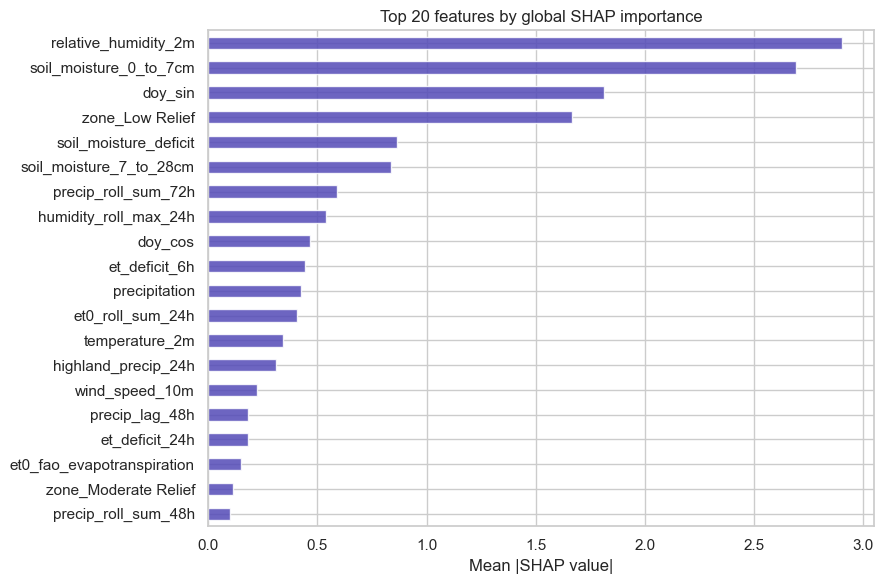

Top 15 features:
relative_humidity_2m      2.9034
soil_moisture_0_to_7cm    2.6915
doy_sin                   1.8144
zone_Low Relief           1.6646
soil_moisture_deficit     0.8640
soil_moisture_7_to_28cm   0.8379
precip_roll_sum_72h       0.5916
humidity_roll_max_24h     0.5414
doy_cos                   0.4667
et_deficit_6h             0.4437
precipitation             0.4272
et0_roll_sum_24h          0.4054
temperature_2m            0.3403
highland_precip_24h       0.3094
wind_speed_10m            0.2238


In [22]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_ser = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
shap_ser.sort_values().plot(kind='barh', ax=ax, color='#534AB7', alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features by global SHAP importance')
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(shap_ser.head(15).to_string())

### 6.2 · SHAP summary plot (beeswarm)

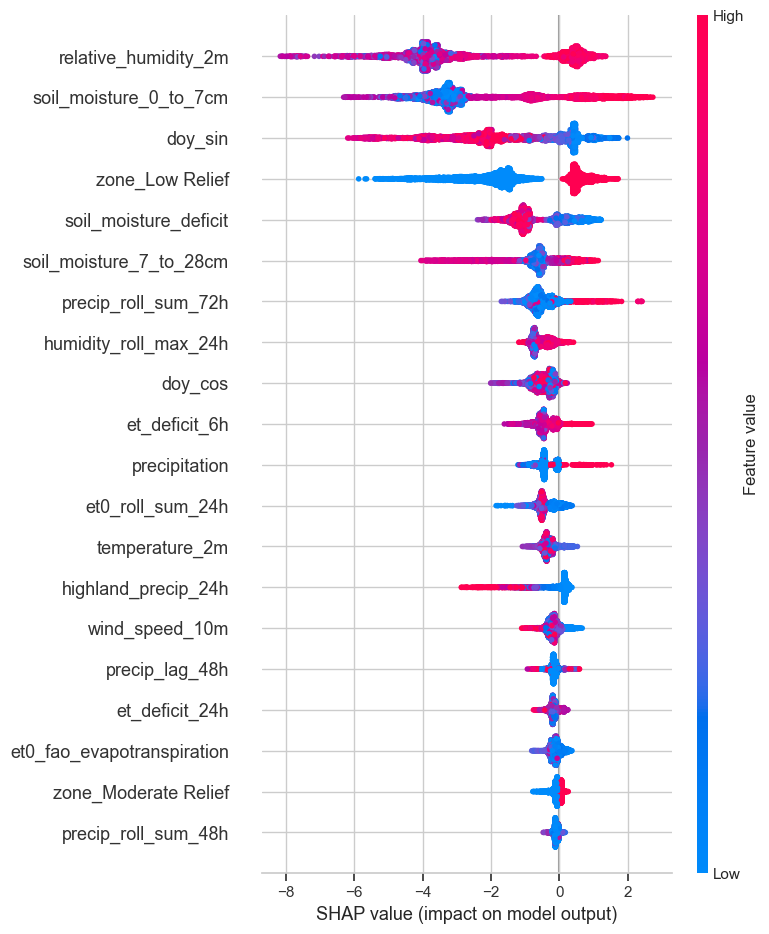

In [23]:
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feature_cols,
                  max_display=20,
                  show=True)

### 6.3 · SHAP dependence plots — top 4 features

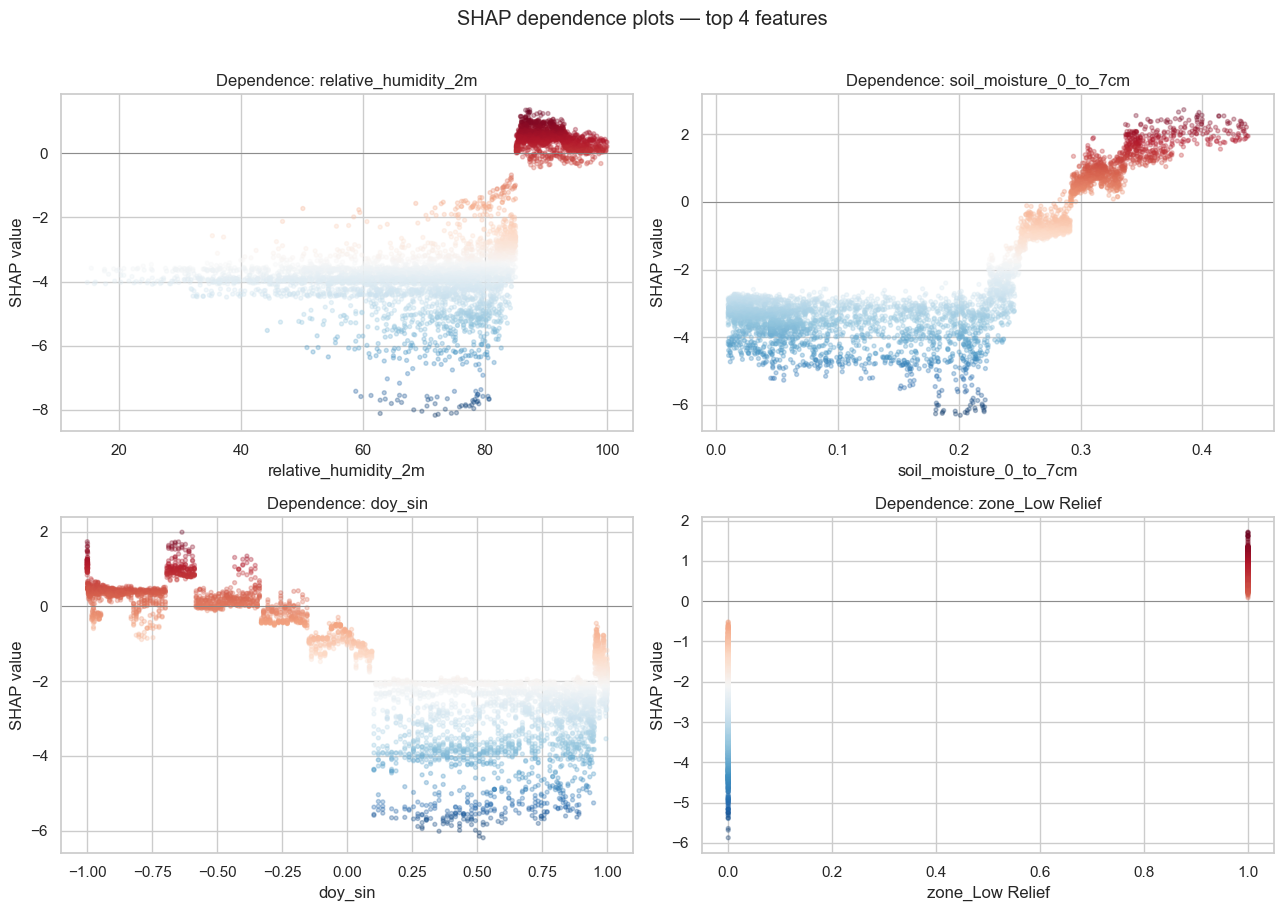

In [24]:
top4 = shap_ser.index[:4].tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flatten(), top4):
    if feat not in X_test_enc.columns:
        continue
    idx = feature_cols.index(feat)
    ax.scatter(X_test_enc[feat], shap_values[:, idx],
               alpha=0.3, s=8, c=shap_values[:, idx],
               cmap='RdBu_r')
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'Dependence: {feat}')

plt.suptitle('SHAP dependence plots — top 4 features', y=1.01)
plt.tight_layout()
plt.show()

## 7 · Live 15-Day Flood Risk Forecast

Fetches real-time data from Open-Meteo, processes through the Sentinel pipeline,
and scores with the trained model.

In [25]:
# 7.1 Fetch live forecast
df_forecast_raw = ingestion.fetch_all_forecast(forecast_days=config.FORECAST_DAYS)
print(f"Live forecast: {len(df_forecast_raw):,} hourly rows across "
      f"{df_forecast_raw['zone'].nunique()} zones")
df_forecast_raw.head(3)

Live forecast: 1,080 hourly rows across 3 zones


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,zone
0,2026-04-29 00:00:00,11.1000,43,0.0000,15.5000,0.0750,0.2580,10.2000,0.0800,High Relief
1,2026-04-29 01:00:00,11.4000,43,0.0000,11.3000,0.0750,0.2580,9.9000,0.0600,High Relief
2,2026-04-29 02:00:00,11.2000,43,0.0000,9.7000,0.0760,0.2580,9.9000,0.0500,High Relief


In [26]:
# 7.2 Run through Sentinel pipeline (Silver stream → Gold features)
df_features = pipeline.run_forecast_pipeline(df_forecast_raw)
print(f"Engineered features: {df_features.shape}")
df_features.head(3)

Engineered features: (357, 39)


,zone,time_6h,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_temperature_0_to_7cm,et0_fao_evapotranspiration,precip_lag_6h,precip_lag_12h,precip_lag_24h,precip_lag_48h,temp_lag_24h,precip_roll_sum_24h,precip_roll_sum_48h,precip_roll_sum_72h,precip_roll_max_24h,humidity_roll_max_24h,et0_roll_sum_24h,api_7d,soil_saturation_index,soil_moisture_change_6h,soil_moisture_deficit,frozen_ground_flag,temp_trend_24h,et_deficit_6h,et_deficit_24h,humidity_precip_product,highland_precip_24h,zone_cascade_risk,hour_sin,hour_cos,doy_sin,doy_cos,is_winter,dq_score,is_flood
0,High Relief,2026-04-29 12:00:00,13.8167,48.6667,0.0000,17.4167,0.0955,0.2580,12.1833,1.4900,0.0000,0.0000,0.0000,0.0000,14.0167,0.0000,0.0000,0.0000,0.0000,55.3333,3.1400,0.0000,0.1767,0.0038,0.2732,0,-0.2000,-1.4900,-3.1400,0.0000,0.0000,0.0000,0.0000,-1.0000,0.8881,-0.4597,0,1.0000,0
1,High Relief,2026-04-29 18:00:00,11.4167,61.0000,0.0000,16.3333,0.1010,0.2573,10.2667,0.4600,0.0000,0.0000,0.0000,0.0000,11.1833,0.0000,0.0000,0.0000,0.0000,61.0000,2.8800,0.0000,0.1792,0.0055,0.2708,0,0.2333,-0.4600,-2.8800,0.0000,0.0000,0.0000,-1.0000,-0.0000,0.8881,-0.4597,0,1.0000,0
2,High Relief,2026-04-30 00:00:00,10.5167,76.5000,0.0000,2.7167,0.1045,0.2570,9.0167,0.0000,0.0000,0.0000,0.0000,0.0000,10.8500,0.0000,0.0000,0.0000,0.0000,76.5000,2.6300,0.0000,0.1808,0.0035,0.2692,0,-0.3333,0.0000,-2.6300,0.0000,0.0000,0.0000,0.0000,1.0000,0.8800,-0.4750,0,1.0000,0


In [27]:
import importlib
import src.model as mdl

# Force Python to read the new version of model.py
importlib.reload(mdl)

<module 'src.model' from 'C:\\Users\\TEXNO\\PycharmProjects\\Ironhack_Weather_Prediction\\Weather-Prediction\\src\\model.py'>

In [28]:
# 7.3 Score with trained model
checkpoint   = mdl.load_model()
df_predicted = mdl.predict(df_features, checkpoint=checkpoint)

# Summary alert table
summary = (df_predicted
    .groupby('zone')
    .agg(
        max_risk  =('risk_score', 'max'),
        mean_risk =('risk_score', 'mean'),
        high_risk_periods=('risk_score', lambda x: (x >= config.RISK_HIGH).sum()),
        med_risk_periods =('risk_score', lambda x: ((x >= config.RISK_MEDIUM) & (x < config.RISK_HIGH)).sum()),
    )
    .round(3)
    .sort_values('max_risk', ascending=False)
)
print("\n── Zone Risk Summary ─────────────────────────────────────────")
print(summary.to_string())


── Zone Risk Summary ─────────────────────────────────────────
                 max_risk  mean_risk  high_risk_periods  med_risk_periods
zone                                                                     
Low Relief         0.0050     0.0000                  0                 0
High Relief        0.0010     0.0000                  0                 0
Moderate Relief    0.0000     0.0000                  0                 0


### 7.4 · Forecast risk score — 15-day time series

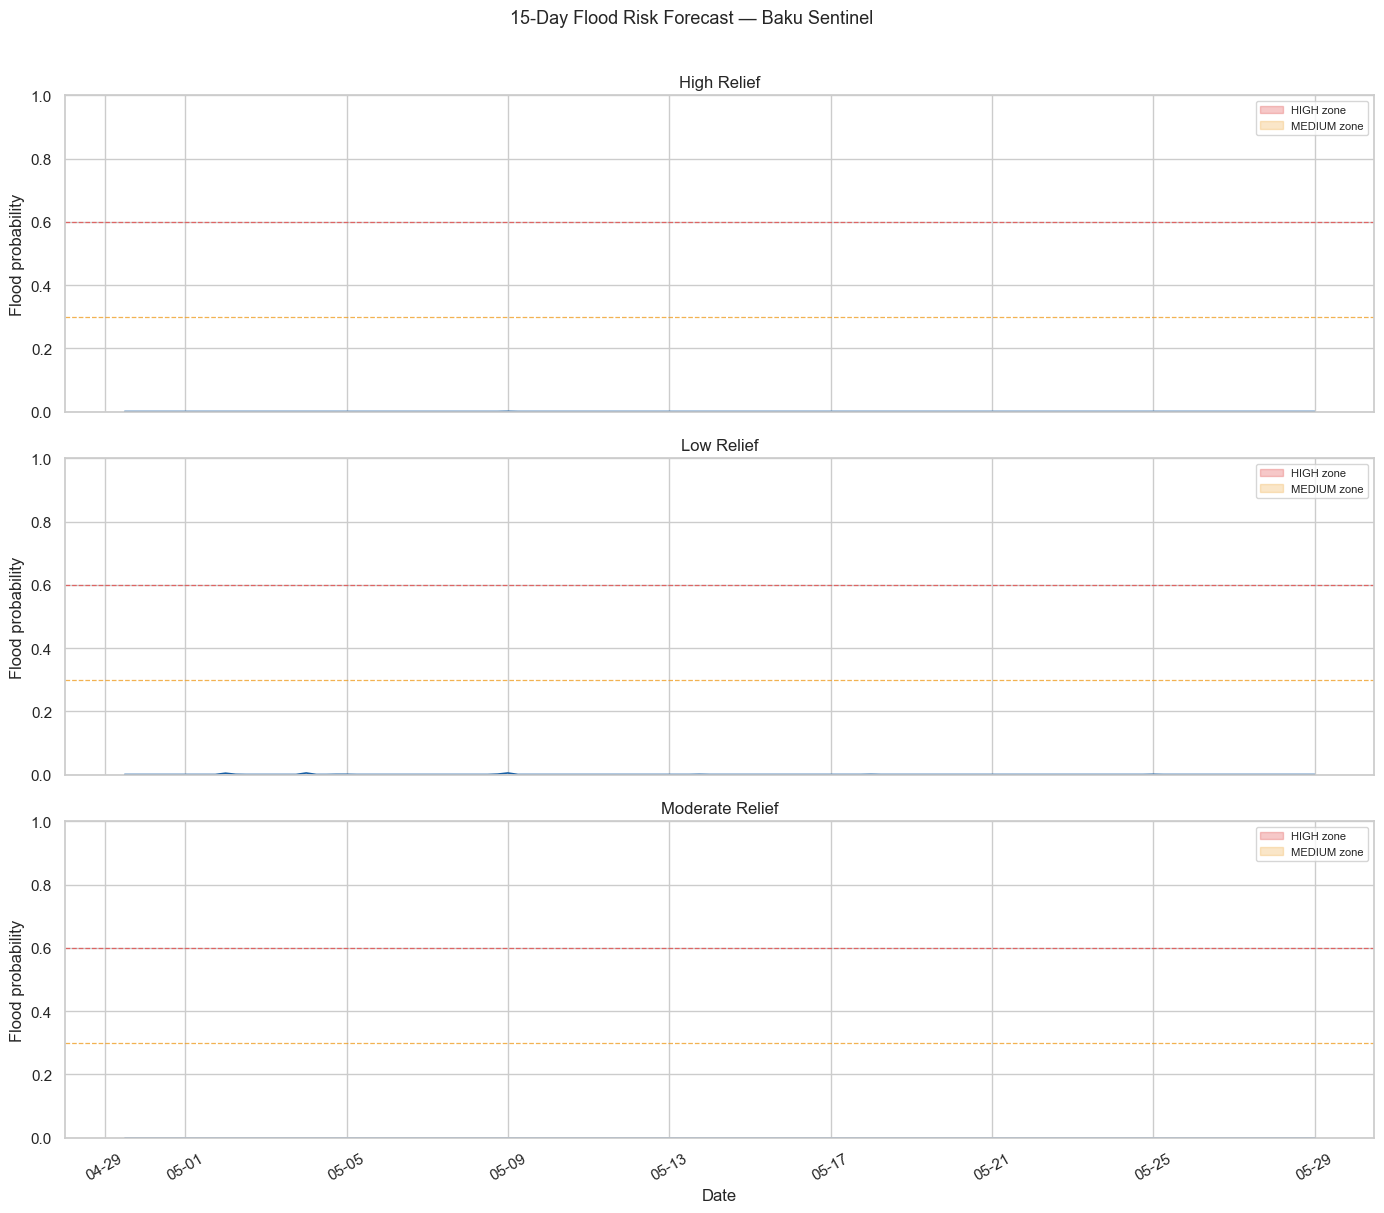

In [29]:
fig, axes = plt.subplots(len(config.BAKU_ZONES), 1,
                          figsize=(14, 4 * len(config.BAKU_ZONES)), sharex=True)

for ax, zone_cfg in zip(axes, config.BAKU_ZONES):
    zone = zone_cfg['zone']
    zdf  = df_predicted[df_predicted['zone'] == zone].sort_values('time_6h')

    ax.fill_between(zdf['time_6h'], zdf['risk_score'],
                    where=zdf['risk_score'] >= config.RISK_HIGH,
                    alpha=0.3, color='#E24B4A', label='HIGH zone')
    ax.fill_between(zdf['time_6h'], zdf['risk_score'],
                    where=(zdf['risk_score'] >= config.RISK_MEDIUM) & (zdf['risk_score'] < config.RISK_HIGH),
                    alpha=0.25, color='#EF9F27', label='MEDIUM zone')
    ax.plot(zdf['time_6h'], zdf['risk_score'], lw=1.2, color='#185FA5')

    ax.axhline(config.RISK_HIGH,   color='#E24B4A', linestyle='--', lw=0.9, alpha=0.8)
    ax.axhline(config.RISK_MEDIUM, color='#EF9F27', linestyle='--', lw=0.9, alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Flood probability')
    ax.set_title(f'{zone}')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
axes[-1].set_xlabel('Date')
plt.suptitle(f'15-Day Flood Risk Forecast — Baku Sentinel', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 7.5 · Alert summary

In [30]:
ALERT_ICONS = {'HIGH': '⚠️ ', 'MEDIUM': '🟡', 'LOW': '🟢'}

for _, row in summary.iterrows():
    zone      = row.name
    max_risk  = row['max_risk']
    high_p    = int(row['high_risk_periods'])
    if max_risk >= config.RISK_HIGH:
        level = 'HIGH'
    elif max_risk >= config.RISK_MEDIUM:
        level = 'MEDIUM'
    else:
        level = 'LOW'
    icon = ALERT_ICONS[level]
    print(f"{icon}  {zone:20s}  peak={max_risk*100:.1f}%  "
          f"high-risk 6h-periods={high_p}  level={level}")

🟢  Low Relief            peak=0.5%  high-risk 6h-periods=0  level=LOW
🟢  High Relief           peak=0.1%  high-risk 6h-periods=0  level=LOW
🟢  Moderate Relief       peak=0.0%  high-risk 6h-periods=0  level=LOW
